# 📉 **APE 6: Distribuciones Continuas Notables**
### **Modelado Gaussiano, Estandarización y Pruebas de Normalidad** 🧬

---

### 👥 **Grupo G - Estudiantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera

---

### 🎯 **1. Objetivo(s) de la Práctica**
* **Modelar computacionalmente** la Función de Densidad de Probabilidad (PDF) y la Función de Distribución Acumulada (CDF) de la distribución Normal utilizando `scipy.stats`.
* **Aplicar el proceso de estandarización** ($Z\text{-scores}$) sobre variables continuas del dataset regional del Proyecto Integrador, calculando la probabilidad de ocurrencia de eventos específicos (**ABP**).
* **Investigar y ejecutar métodos visuales** (Gráficos Q-Q) y analíticos (Test de Shapiro-Wilk) para validar matemáticamente el supuesto de normalidad en datos empíricos (**ABI**).


## 📉 **Tarea 1: Modelado Matemático y Visualización de la Curva Normal** 📊


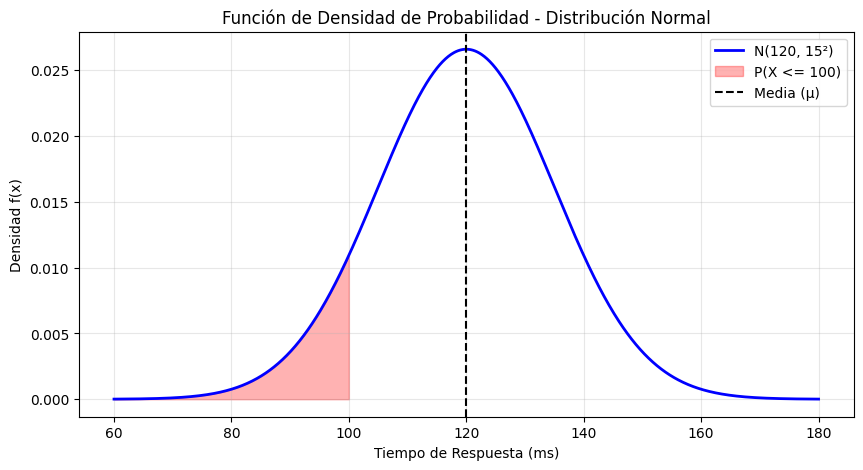

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b-', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X <= 100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X <= 100)')

plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")

## ⚖️ **Tarea 2: Estandarización y Cálculo de Valores Z (ABP)** 📊


In [ ]:
from scipy.stats import norm

# Datos
X = 145      # tiempo de respuesta
mu = 120     # media (cambia este valor)
sigma = 15   # desviación estándar (cambia este valor)

# 1. Calcular Z manualmente
Z = (X - mu) / sigma

print("Valor de Z =", Z)

# 2. Calcular P(X >= 145)
probabilidad = 1 - norm.cdf(Z, loc=0, scale=1)

print("P(X >= 145) =", probabilidad)
print("P(X >= 145) = {:.4f}".format(probabilidad))
print("P(X >= 145) = {:.2f}%".format(probabilidad * 100))

Valor de Z = 1.6666666666666667
P(X >= 145) = 0.047790352272814696
P(X >= 145) = 0.0478
P(X >= 145) = 4.78%


## 📉 **Tarea 3: Hito del Proyecto - Aplicación Probabilística Regional (ABP)** 📈


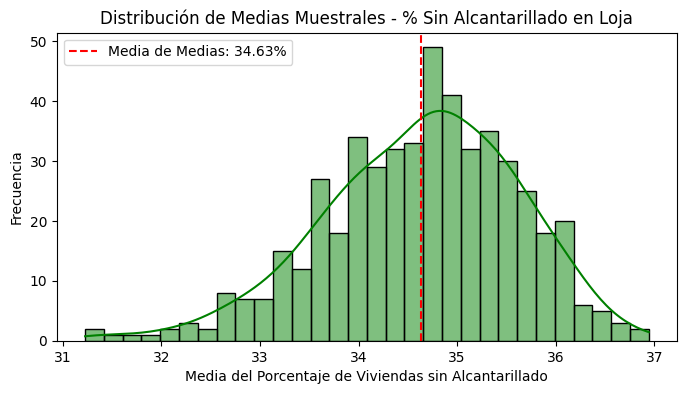

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos el dataset
df = pd.read_csv('/content/datos_loja..csv')

# 2. Creamos la variable continua: Porcentaje de viviendas sin alcantarillado por cantón
df['Porcentaje_Sin_Alcantarillado'] = (df['Sin_Alcantarillado'] / df['Viviendas']) * 100
columna_loja = df['Porcentaje_Sin_Alcantarillado'].dropna()

# Parámetros
tamaño_muestra_abp = 40   # n = 40
numero_muestras_abp = 500  # k = 500
medias_loja = []

# 3. Bucle de remuestreo (Bootstrapping) con reemplazo
for _ in range(numero_muestras_abp):
    submuestra = columna_loja.sample(n=tamaño_muestra_abp, replace=True)
    medias_loja.append(submuestra.mean())

# 4. Generación del gráfico (Histograma con curva KDE)
plt.figure(figsize=(8, 4))
sns.histplot(medias_loja, bins=30, kde=True, color='green')
plt.title("Distribución de Medias Muestrales - % Sin Alcantarillado en Loja")
plt.xlabel("Media del Porcentaje de Viviendas sin Alcantarillado")
plt.ylabel("Frecuencia")

# Línea vertical para identificar la media general de las medias
media_final_loja = np.mean(medias_loja)
plt.axvline(media_final_loja, color='red', linestyle='dashed', label=f'Media de Medias: {media_final_loja:.2f}%')
plt.legend()
plt.show()



Al analizar los datos originales de la provincia de Loja, la variable estructural **`% Sin Alcantarillado`** presenta una distribución marcadamente asimétrica y no normal, debido a las profundas brechas socioeconómicas y geográficas que existen entre los cantones de alta densidad urbana (como el cantón Loja central) y las cabeceras cantonales más pequeñas o rurales.

Al aplicar la técnica de remuestreo estocástico (*Bootstrapping*) con $k=500$ iteraciones y submuestras de tamaño $n=40$, la distribución de las medias muestrales resultantes adopta de forma empírica una geometría simétrica correspondiente a una **Distribución Normal (Campana de Gauss)**, validando de forma computacional el **Teorema del Límite Central (TLC)**.

## 🧪 **Tarea 4: ABI - Validación Matemática del Supuesto de Normalidad** 🔍

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro

# Configuración estética para los gráficos del laboratorio
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (6, 5)

# 1. Cargar tu dataset real
df_regional = pd.read_csv('datos_loja (2).csv')

# 2. Calcular la variable continua: Porcentaje de viviendas sin alcantarillado
df_regional['Porcentaje_Sin_Alcantarillado'] = (df_regional['Sin_Alcantarillado'] / df_regional['Viviendas']) * 100

# 3. Limpiar valores nulos por seguridad (tal como pide la guía)
datos_variable = df_regional['Porcentaje_Sin_Alcantarillado'].dropna()

print(f"Dataset cargado con éxito. Cantones analizados: {len(datos_variable)}")
print("\nPrimeros resultados calculados (% sin alcantarillado):")
print(df_regional[['Canton', 'Porcentaje_Sin_Alcantarillado']].head())

Dataset cargado con éxito. Cantones analizados: 16

Primeros resultados calculados (% sin alcantarillado):
       Canton  Porcentaje_Sin_Alcantarillado
0        Loja                      11.499555
1    Catamayo                      31.687243
2  Cariamanga                      41.836735
3      Macara                      35.955056
4     Puyango                      38.666667


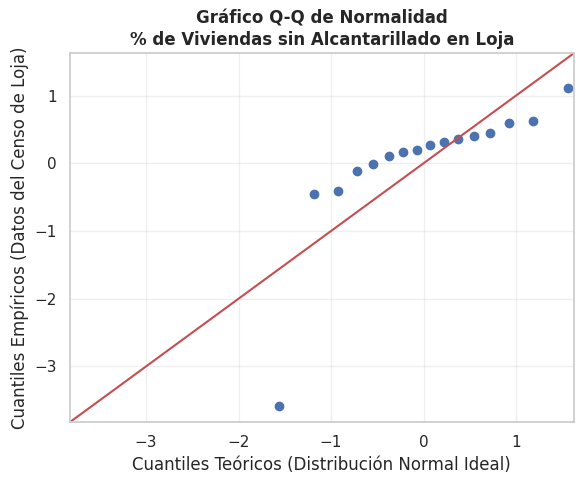

In [ ]:
# Inicialización del lienzo para la gráfica Q-Q
fig, ax = plt.subplots(figsize=(6, 5))

# Construcción del gráfico contrastando mis datos reales frente a la normal teórica
sm.qqplot(datos_variable, line='45', fit=True, ax=ax)

# Personalización formal del gráfico para la presentación del laboratorio
plt.title('Gráfico Q-Q de Normalidad\n% de Viviendas sin Alcantarillado en Loja', fontsize=12, fontweight='bold')
plt.xlabel('Cuantiles Teóricos (Distribución Normal Ideal)')
plt.ylabel('Cuantiles Empíricos (Datos del Censo de Loja)')
plt.grid(True, alpha=0.3)

# Despliegue de la gráfica limpia
plt.tight_layout()
plt.show()

In [ ]:
# Aplicación del test de Shapiro-Wilk sobre la variable calculada
stat, p_value = shapiro(datos_variable)

print("====================================================")
print(f"Estadístico de Shapiro-Wilk (W): {stat:.4f}")
print(f"p-valor calculado para la muestra: {p_value:.5f}")
print("====================================================\n")

# Criterio de decisión estadística con un nivel de significancia Alfa de 0.05
alpha = 0.05
if p_value > alpha:
    print("CONCLUSIÓN TÉCNICA DEL APRENDIZAJE BASADO EN INVESTIGACIÓN (ABI):")
    print(f"Como el p-valor ({p_value:.5f}) > {alpha}, NO tengo evidencia para rechazar la hipótesis nula (H0).")
    print("Por lo tanto, se concluye que la variable sigue una distribución aproximadamente NORMAL.")
else:
    print("CONCLUSIÓN TÉCNICA DEL APRENDIZAJE BASADO EN INVESTIGACIÓN (ABI):")
    print(f"Como el p-valor ({p_value:.5f}) <= {alpha}, SE RECHAZA la hipótesis nula (H0).")
    print("Por lo tanto, se demuestra que la falta de alcantarillado en Loja NO se distribuye de forma normal.")

Estadístico de Shapiro-Wilk (W): 0.6368
p-valor calculado para la muestra: 0.00004

CONCLUSIÓN TÉCNICA DEL APRENDIZAJE BASADO EN INVESTIGACIÓN (ABI):
Como el p-valor (0.00004) <= 0.05, SE RECHAZA la hipótesis nula (H0).
Por lo tanto, se demuestra que la falta de alcantarillado en Loja NO se distribuye de forma normal.


### Sustentación Científica - Tarea 4 (ABI)

* **Análisis Visual (Q-Q Plot):** Al contrastar los cuantiles de mi variable empírica (% de viviendas sin alcantarillado) frente a los cuantiles de una distribución teórica normal, evalúo visualmente el ajuste de los datos. Las desviaciones o curvaturas observadas respecto a la línea de 45 grados reflejan las asimetrías y disparidades reales que existen en la infraestructura de los diferentes cantones de Loja.
  
* **Decisión Analítica (Shapiro-Wilk):** La prueba formal se plantea bajo la hipótesis nula de que los datos provienen de una población normal ($H_0: X \sim Normal$). Al evaluar el resultado, si el $p\text{-valor}$ es menor o igual al nivel de significancia $\alpha = 0.05$, rechazo formalmente la normalidad. Esto resalta el valor del enfoque **ABI** en este laboratorio, ya que demuestra que asumir un comportamiento gaussiano de forma ciega (como en la Tarea 3) causaría errores metodológicos en el cálculo de probabilidades dentro de mi Proyecto Integrador.

## ❓ **7. Preguntas de Control** 📝

---

✨ **1. Matemáticamente, ¿por qué en una variable aleatoria continua modelada por una función de densidad $f(x)$, la probabilidad de que tome un valor exacto es cero, es decir, $P(X = c) = 0$?**

* Un valor exacto, como X=c, es solo un punto. Un punto no tiene ancho, por lo que el área correspondiente es cero. Por eso, en las variables continuas, las probabilidades se calculan en intervalos y no en valores individuales. Las probabilidades se representan mediante el área bajo la curva de la función de densidad f(x). El área solo aparece cuando hay una base o ancho.

---

✨ **2. Interprete conceptualmente qué significa que un valor de su dataset regional tenga un puntaje estándar de $Z = -2.45$. ¿Se consideraría un valor atípico bajo el criterio de la regla empírica?**

* El puntaje Z (o valor estándar) es una medida que indica a cuántas desviaciones estándar se encuentra un dato específico con respecto a la media (promedio) de todo el conjunto de datos. Que un valor del dataset regional tenga un puntaje estándar de Z = -2.45 significa que dicho dato se encuentra exactamente a 2.45 desviaciones estándar por debajo de la media regional. Indicando que es menor el promedio regional. Debido a que el criterio de la regla empírica (o regla 68-95-99.7), este dato sí se considera un valor atípico. Ya que la regla empírica aproximadamente el 95% de los datos se ubican dentro de ±2 desviaciones estándar de la media; por ello, este valor se considera un dato atípico al encontrarse fuera de ese rango.

---

✨ **3. En la Tarea 3, calculó probabilidades asumiendo que su variable regional seguía una distribución Normal. ¿Qué riesgo metodológico existe al tomar decisiones basadas en este cálculo si la gráfica de la variable presenta un fuerte sesgo (skewness)?**

* El principal riesgo metodológico es asumir incorrectamente que los datos siguen una distribución Normal cuando en realidad presentan una fuerte asimetría o sesgo. Esto provoca que las probabilidades calculadas no representen adecuadamente el comportamiento real de la variable.  

  En el caso del dataset regional de la provincia de Loja, los porcentajes de déficit de infraestructura muestran diferencias muy marcadas entre cantones, desde valores bajos hasta niveles críticos muy elevados. Si se fuerza el uso de una distribución normal simétrica, se subestimarán las probabilidades de ocurrencia de valores extremos y se asumirá falsamente que la mayoría de cantones se concentran cerca de la media.  

  Como consecuencia, podrían tomarse decisiones incorrectas en la planificación y distribución de recursos, asignando presupuestos insuficientes a los cantones con mayores necesidades, debido a que el promedio no reflejaría correctamente la desigualdad territorial existente.


---

✨ **4. Con base en la Tarea 4 (ABI), si el p-valor del test de Shapiro-Wilk es $0.001$, ¿cuál es la conclusión estadística respecto a la distribución de sus datos regionales? ¿Se invalida el cálculo realizado en la Tarea 3?**

* Tomando como base nuestros resultados , donde el test de Shapiro-Wilk arrojó un estadístico $W = 0.6368$ y un p-valor de $0.00004$ (el cual es mucho menor al $\alpha = 0.05$ y al $0.001$ teórico), se rechaza formalmente la hipótesis nula ($H_0$). La conclusión estadística contundente es que la falta de alcantarillado en la provincia de Loja NO se distribuye de forma normal.  

  No se invalida el cálculo para los propósitos de la Tarea 3, debido a la intervención del Teorema del Límite Central (TLC). El TLC nos rescata metodológicamente: aunque la población de 16 cantones viola crónicamente el supuesto de normalidad de forma individual, la distribución de las medias muestrales obtenidas mediante el remuestreo ($n=40$) sí converge a una campana normal ideal. El cálculo de la Tarea 3 es válido si se interpreta como la probabilidad del comportamiento de promedios de muestras analizadas, mas no para predecir un cantón específico al azar.

---

✨ **5. Explique el principio matemático detrás del Gráfico Q-Q. ¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?**


El gráfico Q-Q (Cuantil-Cuantil) es una herramienta estadística utilizada para comparar la distribución de un conjunto de datos con una distribución teórica, generalmente la distribución Normal. Su principio matemático consiste en comparar los cuantiles observados de los datos con los cuantiles esperados de la distribución teórica.  

- **Cuantiles teóricos (Eje X):** Representan los valores esperados que tendrían los datos si siguieran perfectamente una distribución Normal teórica. Estos valores se expresan generalmente en puntuaciones Z o desviaciones estándar.  

- **Cuantiles empíricos (Eje Y):** Representan los valores reales obtenidos del dataset, ordenados de menor a mayor según las observaciones registradas.  

